In [ ]:
# !pip install boruta pycaret scikit-learn imbalanced-learn -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from boruta import BorutaPy
from sklearn.preprocessing import MinMaxScaler
import io
from contextlib import redirect_stdout

In [ ]:
data=pd.read_csv(r"../../data/processed/data_final_shift.csv")

,Date,Shanghai Comp,KODEX 200,TOPIX,NASDAQ,KOSDAQ,Brent Crude Oil,Gold Spot,JPY/KRW,USD/KRW,...,GJR_VaR_5_t1,Signal1_Buy,Signal1_Sell,Signal2_Buy,Signal2_Sell,Signal3_Buy,Signal3_Sell,Signal4_Buy,Signal4_Sell,Risk_Label
0,2009-04-17,2503.935059,17370.0,875.0,1673.069946,483.799988,51.959999,867.400024,13.371,1325.800049,...,-2.736404,0,0,0,0,0,0,0,0,Low Risk
1,2009-04-20,2557.456055,17480.0,876.0,1608.209961,491.940002,51.959999,887.000000,13.536,1327.500000,...,-2.641002,0,0,0,0,0,0,0,0,Low Risk
2,2009-04-21,2535.827881,17480.0,855.0,1643.849976,497.190002,51.959999,882.099976,13.727,1354.300049,...,-2.553085,0,0,0,0,0,0,0,0,Low Risk
3,2009-04-22,2461.345947,17715.0,856.0,1646.119995,509.899994,51.959999,891.799988,13.726,1346.599976,...,-2.469281,0,0,0,0,0,0,0,0,Low Risk
4,2009-04-23,2463.954102,17895.0,862.0,1652.209961,514.090027,51.959999,905.900024,13.618,1333.599976,...,-2.386329,0,0,0,0,0,1,0,0,Low Risk


### One-Hot Encoding / Train분리

In [14]:
# Label을 0/1로 변환 (Low risk=0, High risk=1)
label_norm = data['Risk_Label'].astype(str).str.strip().str.lower()
label_map = {'low risk': 0, 'high risk': 1}
data['Risk_Label'] = label_norm.map(label_map)

data['Risk_Label'] = data['Risk_Label'].astype(int)

# train:valid:test 5:3:2
data_train = data[:int(len(data) * 0.5)]

# X, y 분리
X_train = data_train.drop(['Risk_Label', 'Date'], axis=1)  # 설명변수, Date는 ML에서 불필요
y_train = data_train['Risk_Label']  # 반응변수

### train:valid:test = 5:3:2

In [16]:
# 랜덤 포레스트 + Boruta (class_weight 2개 자동 실행)

# 랜덤 포레스트
rf = RandomForestClassifier(
    n_jobs=-1,                  #병렬 처리
    class_weight='balanced',            #클래스 불균형 처리(vs 'balanced')
    max_depth=10,             #트리 깊이 제한
    random_state=1              #seed 고정
    )

# BorutaPy 객체 생성
selector = BorutaPy(
    estimator=rf,
    perc=90,              # shadow 기준 (엄격)
    alpha=0.05,            # 유의수준
    max_iter=50,           # Boruta 반복 횟수
    random_state=1,         # seed 고정
    verbose=2             # 진행 상황 출력 
    )

# Boruta 실행
boruta_result=selector.fit(X_train.values, y_train.values)
    
# 결과 저장/확인
result=boruta_result
selected_features = X_train.columns[boruta_result.support_]
        
selected_features

Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	44
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	44
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	44
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	44
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	44
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	44
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	44
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	8
Tentative: 	4
Rejected: 	32
Iteration: 	9 / 50
Confirmed: 	8
Tentative: 	4
Rejected: 	32
Iteration: 	10 / 50
Confirmed: 	8
Tentative: 	4
Rejected: 	32
Iteration: 	11 / 50
Confirmed: 	8
Tentative: 	4
Rejected: 	32
Iteration: 	12 / 50
Confirmed: 	8
Tentative: 	3
Rejected: 	33
Iteration: 	13 / 50
Confirmed: 	8
Tentative: 	3
Rejected: 	33
Iteration: 	14 / 50
Confirmed: 	8
Tentative: 	3
Rejected: 	33
Iteration: 	15 / 50
Confirmed: 	8
Tentative: 	3
Rejected: 	33
Iteration: 	16 / 50
Confirmed: 	8
Tentative: 	3
Rejected: 	33
Iteration: 	17 / 

Index(['NASDAQ', 'JPY/KRW', 'return(%)', 'KOSPI 200_PDI14', 'KOSPI 200_MDI14',
       'KOSPI 200_DMI14', 'GARCH_mu_t1', 'GJR_sigma_t1'],
      dtype='object')

In [5]:
# 변수 중요도 퍼센트 테이블

def build_importance_pct_table(selector):
    feature_names = X_train.columns
    n_features = len(feature_names)

    imp_history = np.array(selector.importance_history_)
    if imp_history.ndim == 1:
        imp_history = imp_history.reshape(1, -1)

    # 실제 feature 구간만 사용
    imp_real = imp_history[:, :n_features].astype(float)

    # 중요도를 퍼센트로 정규화
    imp_real[imp_real == 0] = np.nan
    row_sums = np.nansum(imp_real, axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    imp_pct = 100 * imp_real / row_sums

    # 경고 없는 평균 계산 (all-NaN 열은 0으로 처리)
    valid_counts = np.sum(np.isfinite(imp_pct), axis=0)
    sum_vals = np.nansum(imp_pct, axis=0)
    mean_pct = np.divide(
        sum_vals,
        valid_counts,
        out=np.zeros(n_features, dtype=float),
        where=valid_counts > 0
    )

    table = pd.DataFrame({
        'feature': feature_names,
        'Importance_pct': mean_pct,
        'status': 'Rejected'
    })
    table.loc[selector.support_, 'status'] = 'Confirmed'
    table.loc[selector.support_weak_, 'status'] = 'Tentative'

    return table.sort_values('Importance_pct', ascending=False).reset_index(drop=True)


table_result = build_importance_pct_table(result)

print('balanced 변수 중요도(%)')
display(table_result)

balanced 변수 중요도(%)


,feature,Importance_pct,status
0,KOSPI 200_PDI14,9.534853,Confirmed
1,NASDAQ,8.607331,Confirmed
2,KOSPI 200_DMI14,6.700335,Confirmed
3,GARCH_mu_t1,6.475177,Confirmed
4,GJR_VaR_5_t1,6.070533,Confirmed
5,KOSPI 200_MDI14,6.021440,Confirmed
6,GJR_sigma_t1,5.975880,Confirmed
7,JPY/KRW,5.832997,Confirmed
8,return(%),5.576726,Confirmed
9,TOPIX,5.224922,Confirmed


### 모든 변수

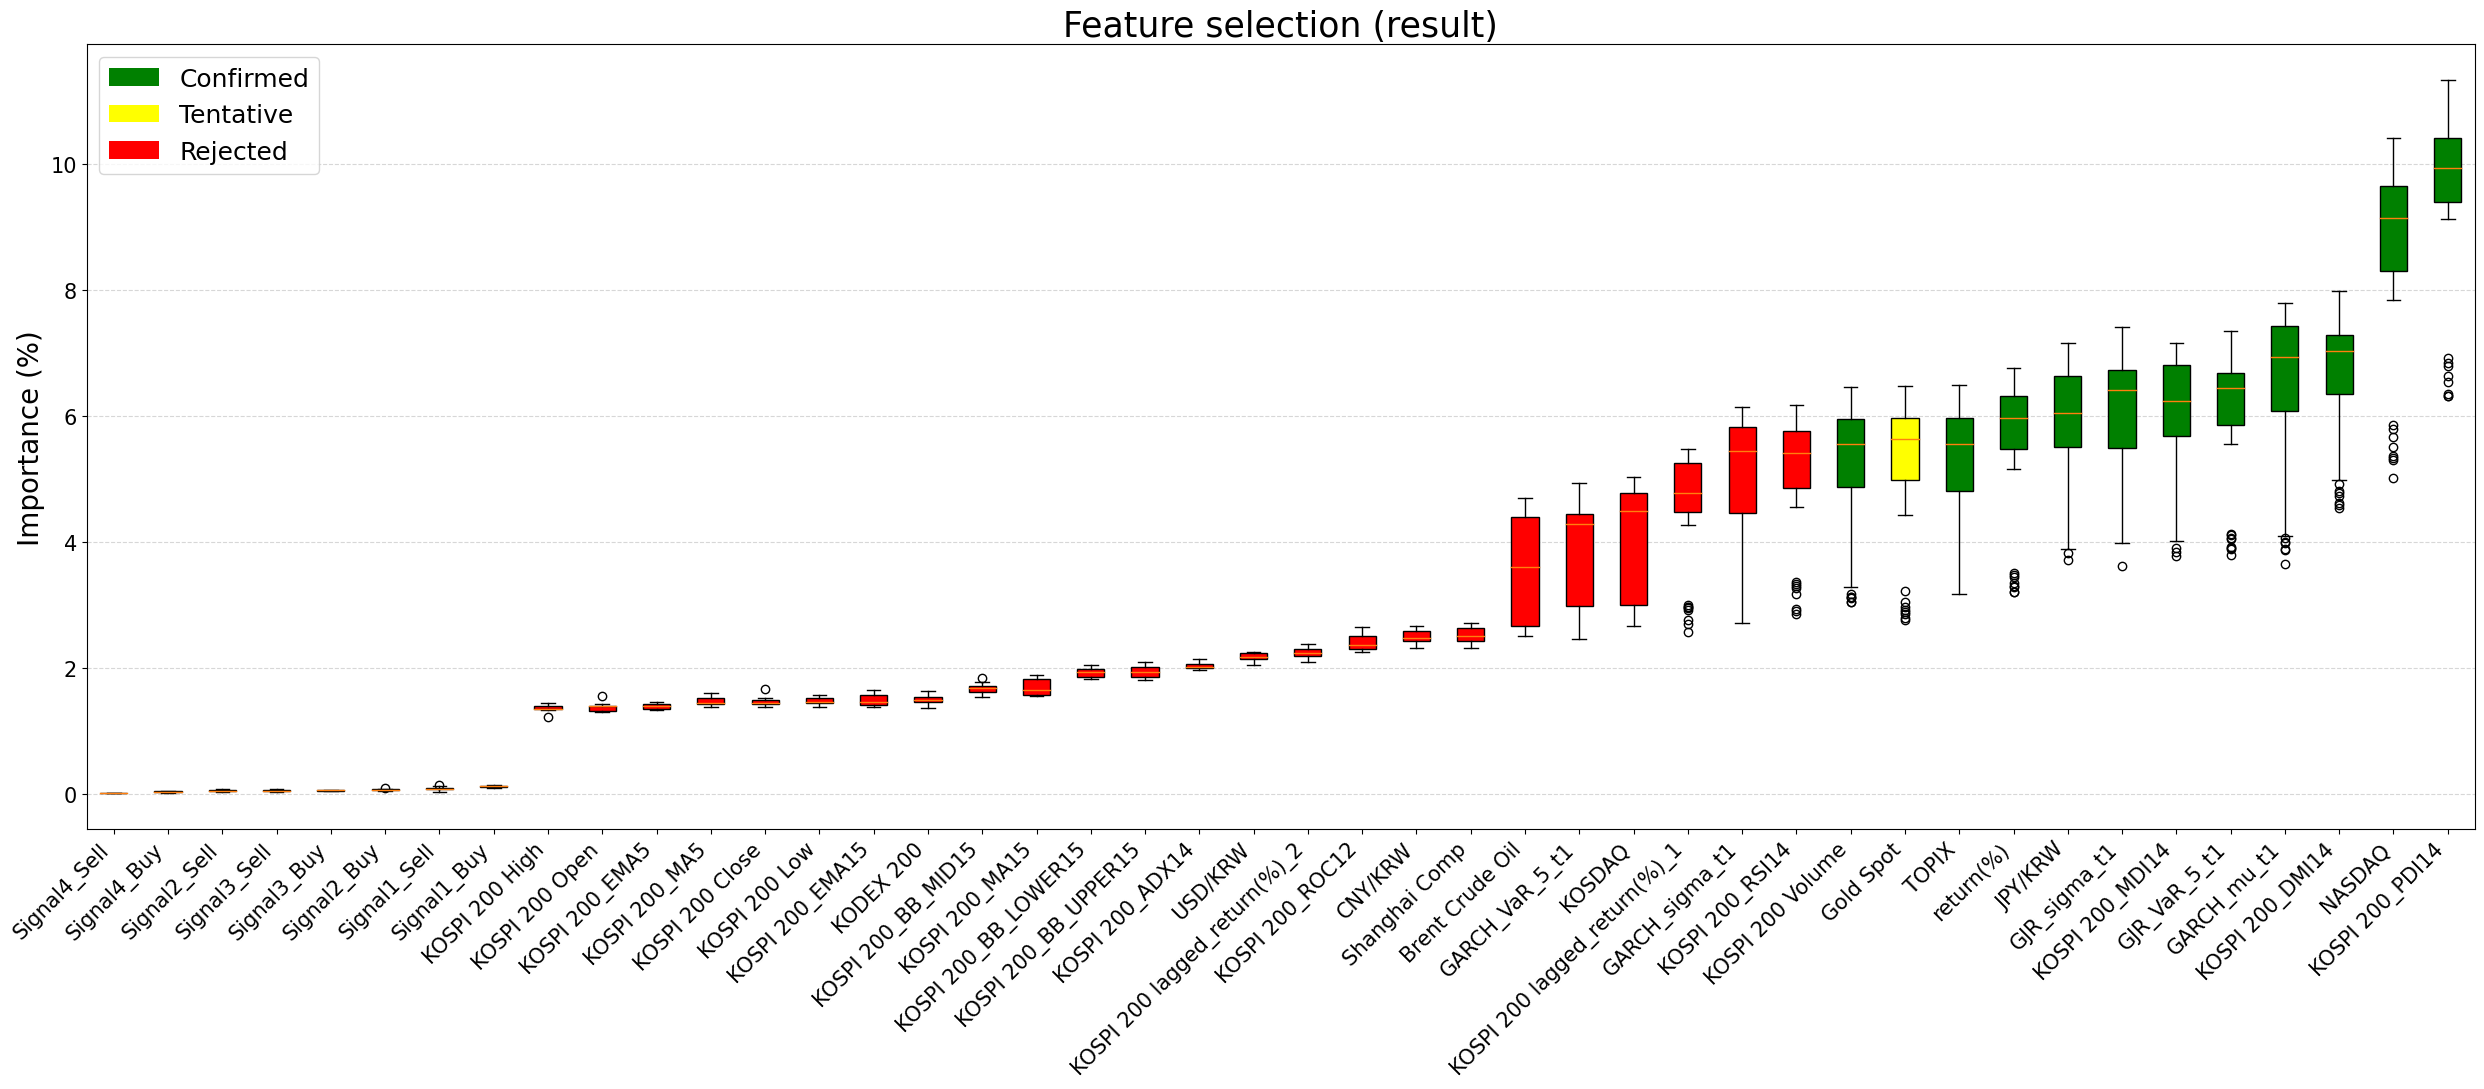

In [6]:

def plot_boruta_result(selector, plot_title):
    feature_names = X_train.columns
    n_features = len(feature_names)

    # Boruta importance history 가져오기
    imp_history = np.array(selector.importance_history_)
    if imp_history.ndim == 1:
        imp_history = imp_history.reshape(1, -1)

    imp_real = imp_history[:, :n_features].astype(float)
    imp_real[imp_real == 0] = np.nan

    # 퍼센트 변환 (분모 0 행은 NaN 유지)
    row_sums = np.nansum(imp_real, axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    imp_pct_local = 100 * imp_real / row_sums

    # 전부 NaN이면 raw importance로 폴백
    use_fallback_raw = np.isnan(imp_pct_local).all()
    plot_values = imp_real if use_fallback_raw else imp_pct_local
    y_label = 'Importance (Z-score)' if use_fallback_raw else 'Importance (%)'

    # 경고 없는 평균 importance 계산 (all-NaN 컬럼은 0)
    valid_counts = np.sum(np.isfinite(plot_values), axis=0)
    sum_vals = np.nansum(plot_values, axis=0)
    mean_imp = np.divide(
        sum_vals,
        valid_counts,
        out=np.zeros(n_features, dtype=float),
        where=valid_counts > 0
    )

    # DataFrame 생성 및 정렬
    feat_df_local = pd.DataFrame({
        'feature': feature_names,
        'mean_importance': mean_imp,
        'status': ['Rejected'] * n_features
    })

    feat_df_local.loc[selector.support_, 'status'] = 'Confirmed'
    feat_df_local.loc[selector.support_weak_, 'status'] = 'Tentative'
    feat_df_local = feat_df_local.sort_values(by='mean_importance', ascending=True)

    # Boxplot 데이터 준비
    sorted_features = feat_df_local['feature'].tolist()
    sorted_status = feat_df_local['status'].tolist()
    sorted_idx = [list(feature_names).index(f) for f in sorted_features]
    values_sorted = plot_values[:, sorted_idx]

    box_data = []
    valid_features = []
    valid_status = []
    for i, feat in enumerate(sorted_features):
        vals = values_sorted[:, i]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        box_data.append(vals)
        valid_features.append(feat)
        valid_status.append(sorted_status[i])

    # 색상 설정
    color_map = {'Confirmed': 'green', 'Tentative': 'yellow', 'Rejected': 'red'}
    box_colors = [color_map[s] for s in valid_status]

    plt.figure(figsize=(25, 11))
    bp = plt.boxplot(box_data, patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)

    plt.xticks(range(1, len(valid_features) + 1), valid_features, rotation=45, ha='right', fontsize=15)
    plt.ylabel(y_label, fontsize=20)
    plt.yticks(fontsize=15)
    plt.title(plot_title, fontsize=25)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    legend_elements = [
        Patch(facecolor='green', label='Confirmed'),
        Patch(facecolor='yellow', label='Tentative'),
        Patch(facecolor='red', label='Rejected')
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=18)
    plt.tight_layout()
    plt.show()

    return feat_df_local, plot_values


feat_df_result, imp_pct_result = plot_boruta_result(result, 'Feature selection (result)')

In [10]:
selected_features=feat_df_result[feat_df_result['status'] != 'Rejected']['feature'].tolist()

data_selected = data[selected_features].copy()
data_selected['Date'] = pd.to_datetime(data['Date'])
data_selected['Risk_Label'] = data['Risk_Label']
data_selected.set_index('Date', inplace=True)
data_selected.head()

,KOSPI 200 Volume,Gold Spot,TOPIX,return(%),JPY/KRW,GJR_sigma_t1,KOSPI 200_MDI14,GJR_VaR_5_t1,GARCH_mu_t1,KOSPI 200_DMI14,NASDAQ,KOSPI 200_PDI14,Risk_Label
Date,,,,,,,,,,,,,
2009-04-17,251600000.0,867.400024,875.0,-0.233192,13.371,1.608928,19.866589,-2.736404,-0.077605,14.647201,1673.069946,34.513789,0
2009-04-20,183300000.0,887.000000,876.0,0.564563,13.536,1.553372,19.670009,-2.641002,-0.074431,12.666581,1608.209961,32.336590,0
2009-04-21,204200000.0,882.099976,855.0,-0.197523,13.727,1.500503,20.389631,-2.553085,-0.073820,9.561273,1643.849976,29.950904,0
2009-04-22,291400000.0,891.799988,856.0,1.408955,13.726,1.453282,19.325617,-2.469281,-0.067794,13.493950,1646.119995,32.819567,0
2009-04-23,277400000.0,905.900024,862.0,0.992765,13.618,1.406416,18.451398,-2.386329,-0.062765,15.409494,1652.209961,33.860892,0


In [11]:
data_selected.to_csv("../../data/processed/data_selected.csv", index=True)